In this Notebook we will be looking at the data from a coffee vending machine in ukraine.
The data used begins in march 2024, and has been updated until the 21st of September 2024. 
The Data includes the day and the time the coffee was sold. The type of payment used, type of drink, 
and ID of buyer is given but will not be used, only the amount per transaction will be used.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [3]:
df = pd.read_csv("index.csv")
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In the data we will be looking to see if there are any patterns in the sales. We will also see if the vending machine is making revenue and worth keeping considering its opening was earlier this year. We will do this through a graph where we will look for any pattern of seasonality or trend throughout the months or weeks. Due to the fact that the machine must be maintained we will look for the best time to do so, taking advantage of the detailed time given. We will also explore the use of the p-value and its applications in finance. We will use some hypothesis testing and data manipulation to explore the probability of next month's sales.

In order to get the data we need and avoid tip toeing around the one we don’t, in our original data frame we will select only the columns we want to use. By grouping the data we are making every day an instance and its value is the total revenue for that day.

In [5]:
# Here we will get the columns date and total sales and print out the head then we will group according to time interval
df_need = df[['date','money']]
print(df_need.head())

         date  money
0  2024-03-01   38.7
1  2024-03-01   38.7
2  2024-03-01   38.7
3  2024-03-01   28.9
4  2024-03-01   38.7


A time series analysis as the name describes is used when we have the date our data was collected. This allows us to explore if there are any daily, weekly, monthly or yearly trends or patterns. In this case we will use a daily analysis given we have a very detailed timestamp and the period for which we have data is not very long. For this we will start with the columns we need and in order to graph it as a time series we will do the following;

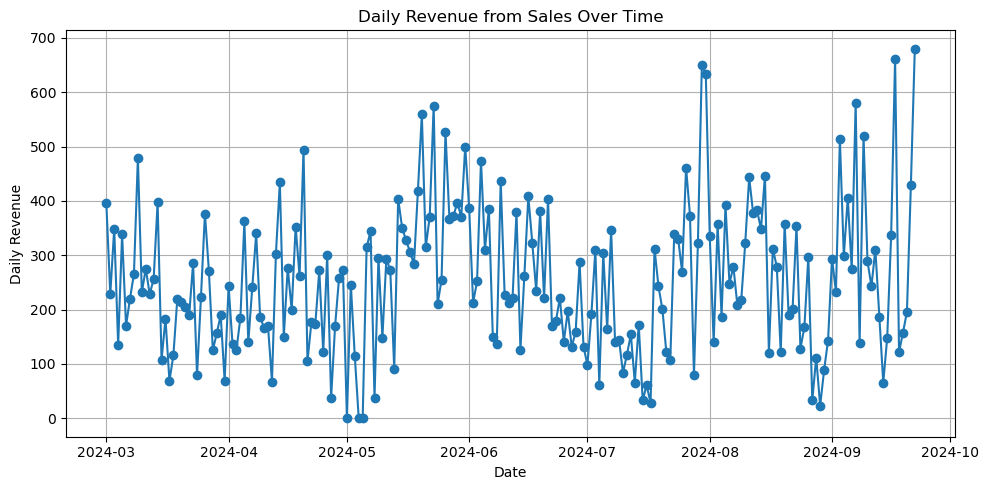

In [7]:
## we will get the two columns we need
df_need = df[['date','money']]
## then we will make it into a pandas data frame
df_need = pd.DataFrame(df_need)
## turn the time from string format into time format
df_need['date'] = pd.to_datetime(df_need['date'])


## we set the index so we can use the date as our x-axis and so we can group by day
df_need.set_index('date', inplace=True)
daily_revenue = df_need.resample('D').sum()
## then we plot
plt.figure(figsize=(10, 5))
plt.plot(daily_revenue.index, daily_revenue['money'], marker='o')
plt.title('Daily Revenue from Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Revenue')
plt.grid()
plt.tight_layout()
plt.show()



Once we obtain the time series we have a list of dates which will be our x-axis and our y axis is our revenue, giving us the graph above. The graph does not show us any seasonality, but it does show us that the sales of coffee have been active, meaning there is revenue therefore worth looking into its future.

Next, we will take a look at the time series in a weekly fashion given that a daily interval did not show any patterns.

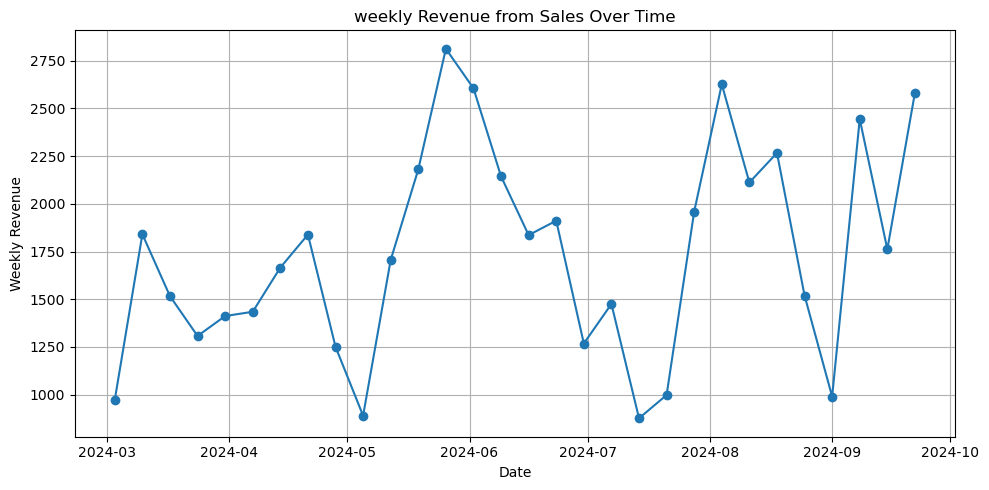

In [9]:
df_need = df[['date','money']]

df_need = pd.DataFrame(df_need)

df_need['date'] = pd.to_datetime(df_need['date'])



df_need.set_index('date', inplace=True)
## we will group by week instead of day with W
daily_revenue = df_need.resample('W').sum()

plt.figure(figsize=(10, 5))
plt.plot(daily_revenue.index, daily_revenue['money'], marker='o')
plt.title('weekly Revenue from Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Revenue')
plt.grid()
plt.tight_layout()
plt.show()

By plotting the weekly sales to get the dates we can see the highest point is behind the beginning of june meaning during may we had the most sales. 

We can also use a time series for simple uses, for example, the vending machine needs to be filed, it need maintenance, therefore it would be useful to know when it’s a good time to do it. In order to determine this, on a 24 hour line we can map the number of purchases at that time of the day throughout the year. 

   datetime    money
0         7   785.16
1         8  2894.90
2         9  3029.54
3        10  5578.36
4        11  4686.44


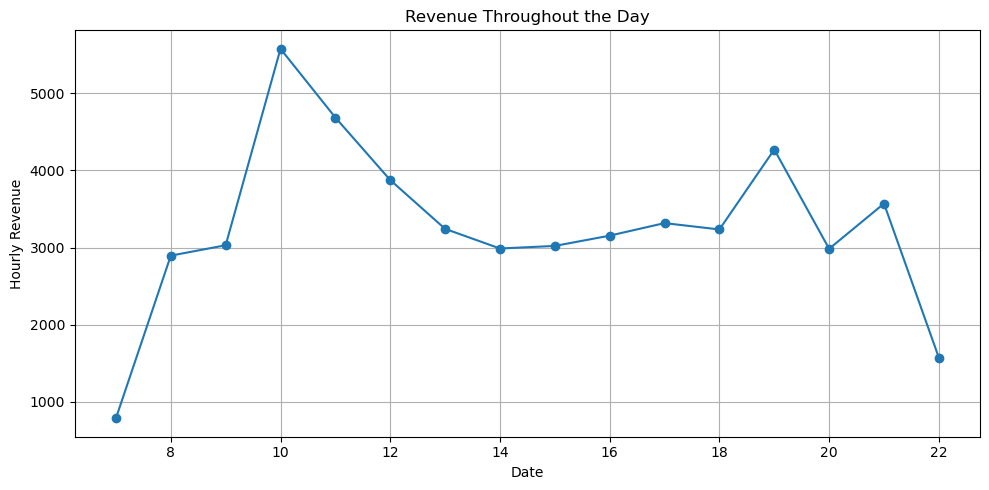

In [11]:
## we make the data frame we need from the original data frame df
df_need = df[['datetime','money']]
## then we make it into a pandas data frame 
df_need = pd.DataFrame(df_need)

## since our data has decimal form milliseconds we will remove them by removing everything after the "."
df['datetime'] = df['datetime'].str.split('.').str[0]
## once this is done we can turn it into a time format column
df_need['datetime'] = pd.to_datetime(df_need['datetime'])

## we get the hours from the whole date and time column 
df_need['datetime'] = df_need['datetime'].dt.hour

# Group by the hour and sum the 'money' column
hourly_revenue = df_need.groupby('datetime')['money'].sum().reset_index()
## we make sure we have the time in hours 
print(hourly_revenue.head())

## then we plot
plt.figure(figsize=(10, 5))
plt.plot(hourly_revenue['datetime'], hourly_revenue['money'], marker='o')
plt.title('Revenue Throughout the Day')
plt.xlabel('Date')
plt.ylabel('Hourly Revenue')
plt.grid()
plt.tight_layout()
plt.show()


The plot then shows us that before 7 Am the vending machine is not used therefore it would be a good time for maintenance or restocking. Also after 22:00 hours there is low usage which makes it possible to also restock the night before or any time until 7 AM.


Since we have seen the ways we can use a Time Series analysis we will now integrate the p-value and it's utility to make predictions and decisions.

The p-value or value of probability is the probability of an event happening.By using the probability of an observation happening we can determine its likely-hood of it happening in the future. In this case we will use it to explore the probability of reaching higher sales or if we had a goal of sales we will see the probability of meeting that goal based on previous sales. 

In this case we will use a test called the Z- test since we have a large number of data.
The Z test lets us choose the confidence level we want, which dictates the lowest probability we allow before we consider the result as too unlikely to happen naturally.

To begin with we will graph the density probability graph for the data grouped by months. This will show us the probability of making a certain amount of money a month based on previous months.




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


   date    money
0     3  7050.20
1     4  6720.56
2     5  9063.42
3     6  7758.76
4     7  6915.94


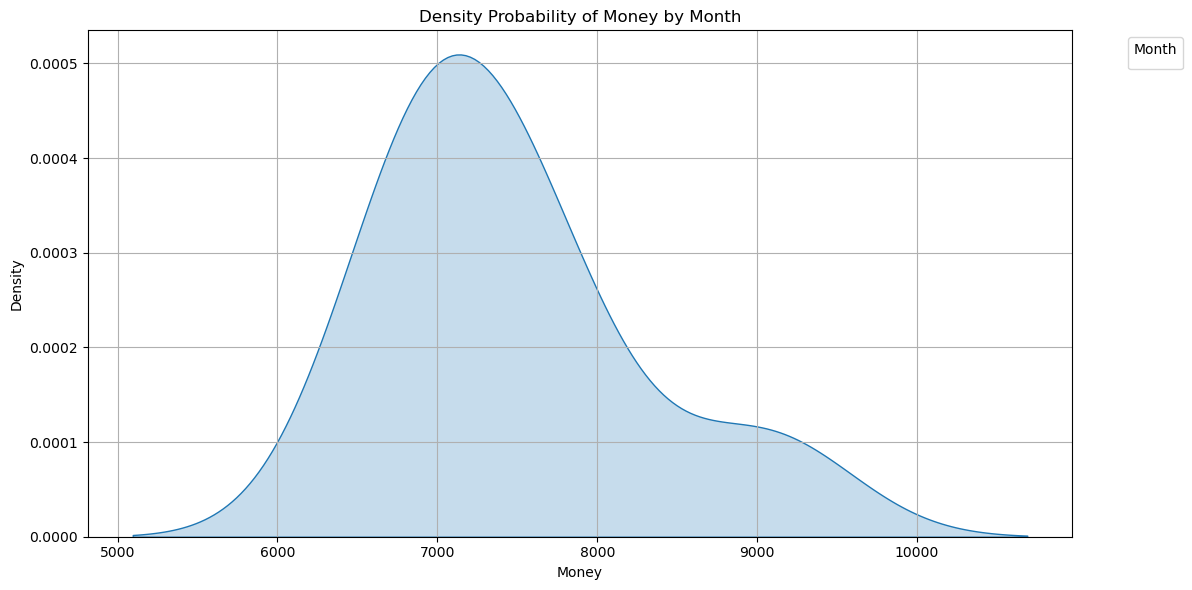

In [13]:

df_need = df[['date','money']]

df_need = pd.DataFrame(df_need)
df['date'] = df['date'].str.split('.').str[0]
df_need['date'] = pd.to_datetime(df_need['date'])

## here we will get the month from the date
df_need['date'] = df_need['date'].dt.month

## then we will group by month then sum the money for that month and make sure we still have a data frame after 
hourly_revenue = df_need.groupby('date')['money'].sum().reset_index()
## make sure we have the months
print(hourly_revenue.head())

## plot using seaborn 
plt.figure(figsize=(12, 6))
sns.kdeplot(data=hourly_revenue, x='money', fill=True, common_norm=False)

# Customize the plot
plt.title('Density Probability of Money by Month')
plt.xlabel('Money')
plt.ylabel('Density')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()

# Show the plot neatly
plt.tight_layout()
plt.show()


Now in the graph we can see that the mean is above 7000 UAH, this means that there is a high probability of getting those sales again. In other words it is very likely that we will make that much money next month.

But what if we want to know the probability of higher sales, say we have a goal of selling 8000 UAH then with the z test we can find the probability.

In [15]:
## get the mean and standard dev
mean_value = hourly_revenue['money'].mean()

std_dev = hourly_revenue['money'].std()

# Display the mean and standard deviation
print(f"The mean of the money column is: {mean_value}")
print(f"The standard deviation of the money column is: {std_dev}")
## target to reach is 8000
## get the z value for that target
z = (8000 - mean_value ) / std_dev 
print(f"The Z- value is: {z}")


The mean of the money column is: 7457.668571428571
The standard deviation of the money column is: 799.8147795464599
The Z- value is: 0.678071276551005


Once we get the mean and Std. Dev. and our revenue target X we can get the z-value and once we compare in a Z-value table available anywhere online, you can get the probability of obtaining said value. Here the P-Value is .2489 or 24.89 percent this means that theres a 25 percent chance we can make 8000 UAH. We can use this to make it a target to reach through advertisement or other means of publicity.


Over All, there are many uses for which taking the time and date of instances helps. For Example, in the weekly summary, If we could backtrack to that week we could figure out the cause of this uproar in sales during this time. Say, if there was an event or a large gathering we can deem this as a random even but if there was a new beverage or a feature was implemented or a poster was put up we could continue using that tactic to keep attracting customers. In addition if we had data on multiple years we could focus on a specific month over the years and see if our current sales are lower than they should be or if they are on par with months from previous years. This helps ensure we are looking at the same season every year making our conclusions and drawings more precise since we are comparing the same time period from different years. 